# 10 - Full Pipeline Assembly

This notebook turns the experiments from Phases 1-9 into one runnable Course QA pipeline.

## Final default

Use the **naive dense similarity pipeline** for the assembled end-to-end system:

- Corpus: PDFs in `data/lectures`
- Cleaning: `clean_corpus(min_content_length=50)`
- Chunking: recursive character splitting, `chunk_size=1000`, `chunk_overlap=200`
- Embeddings: `mxbai_large` / `mxbai-embed-large`
- Retrieval: dense similarity, top-5
- Reranking: disabled by default
- Generation: local `mistral:7b`, temperature `0.0`

Why this default: Phase 9 RAGAS showed that `naive` had the best end-to-end score and lowest generation latency on the 12-question ground truth set. Retrieval-only phases still matter: MMR and cross-encoder reranking improved source ranking on the 5-question retrieval benchmark, but those gains did not translate into the best RAGAS answer quality in Phase 9.

## 0. Setup

In [1]:
import copy
import json
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Resolve project root whether this cell is run from the repo root or notebooks/.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "default.yaml"
MODELS_YAML = PROJECT_ROOT / "configs" / "models.yaml"
LECTURES_DIR = PROJECT_ROOT / "data" / "lectures"
GT_PATH = PROJECT_ROOT / "data" / "evaluation" / "ground_truth.json"
RESULTS_DIR = PROJECT_ROOT / "results"
PERSIST_DIR = PROJECT_ROOT / "vectorstore" / "chroma_db"

print(f"Project root : {PROJECT_ROOT}")
print(f"Lectures     : {LECTURES_DIR}")
print(f"Ground truth : {GT_PATH}")
print(f"Results dir  : {RESULTS_DIR}")
print(f"Chroma DB    : {PERSIST_DIR}")

Project root : /home/hunganh/Code/Python/course_qa_assist
Lectures     : /home/hunganh/Code/Python/course_qa_assist/data/lectures
Ground truth : /home/hunganh/Code/Python/course_qa_assist/data/evaluation/ground_truth.json
Results dir  : /home/hunganh/Code/Python/course_qa_assist/results
Chroma DB    : /home/hunganh/Code/Python/course_qa_assist/vectorstore/chroma_db


## 1. Read Prior Results

The full pipeline should be driven by the measured results, not by whichever component looked best in isolation. This section loads the saved outputs from earlier notebooks and summarizes the decision evidence.

In [2]:
def load_result(filename: str) -> dict:
    path = RESULTS_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing result file: {path}. Re-run the earlier notebook that creates it.")
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

phase1 = load_result("phase1_indexing_baseline.json")
chunking = load_result("chunking_comparison.json")
embeddings_result = load_result("embeddings_comparison.json")
retrieval_result = load_result("retrieval_comparison.json")
reranking_result = load_result("reranking_comparison.json")
ragas_result = load_result("ragas_evaluation.json")

print("Loaded result files from phases 1, 2, 3, 4, 7, and 9.")

Loaded result files from phases 1, 2, 3, 4, 7, and 9.


In [3]:
# Corpus and chunking evidence
chunk_rows = []
for name, values in chunking["strategy_comparison"].items():
    chunk_rows.append({
        "strategy": name,
        "chunks": values.get("num_chunks"),
        "mean_chars": values.get("mean_chars"),
        "avg_top_score": values.get("avg_top_score"),
        "avg_avg_score": values.get("avg_avg_score"),
        "latency_ms": values.get("avg_latency_ms"),
        "coherence": values.get("avg_coherence"),
    })
chunk_df = pd.DataFrame(chunk_rows).set_index("strategy")

# Embedding evidence
embedding_rows = []
for name, values in embeddings_result["models"].items():
    embedding_rows.append({
        "model": name,
        "provider": values["provider"],
        "model_id": values["model_id"],
        "dimensions": values["dimensions"],
        "docs_per_sec": values["throughput"]["docs_per_sec"],
        "query_latency_ms": values["throughput"]["avg_query_latency_ms"],
        "retrieval_top_score": values["retrieval"]["avg_top_score"],
        "retrieval_latency_ms": values["retrieval"]["avg_latency_ms"],
    })
embedding_df = pd.DataFrame(embedding_rows).set_index("model")

# Retrieval-only evidence
retrieval_rows = []
for name, values in retrieval_result["strategies"].items():
    retrieval_rows.append({
        "strategy": name,
        "precision@5": values["avg_precision_at_k"],
        "mrr": values["avg_mrr"],
        "ndcg@5": values["avg_ndcg_at_k"],
        "latency_ms": values["avg_latency_ms"],
    })
retrieval_df = pd.DataFrame(retrieval_rows).set_index("strategy").sort_values("precision@5", ascending=False)

# Reranking evidence
rerank_rows = []
for name, values in reranking_result["techniques"].items():
    rerank_rows.append({
        "technique": name,
        "precision@5": values["avg_precision_at_k"],
        "mrr": values["avg_mrr"],
        "ndcg@5": values["avg_ndcg_at_k"],
        "latency_ms": values["avg_latency_ms"],
    })
rerank_df = pd.DataFrame(rerank_rows).set_index("technique").sort_values("precision@5", ascending=False)

# End-to-end RAGAS evidence
ragas_rows = []
for row in ragas_result["results"]:
    ragas_rows.append({
        "config": row["config"],
        **row["scores"],
        "avg_score": row["avg_score"],
        "avg_latency_ms": row["avg_latency_ms"],
    })
ragas_df = pd.DataFrame(ragas_rows).set_index("config").sort_values("avg_score", ascending=False)

print("Corpus summary")
print(f"  Raw pages    : {phase1['raw_documents']}")
print(f"  Cleaned pages: {phase1['cleaned_docs']}")
print(f"  Chunks       : {phase1['chunks']}")
print(f"  Chunking     : recursive {phase1['chunk_size']}/{phase1['chunk_overlap']}")

Corpus summary
  Raw pages    : 2703
  Cleaned pages: 2666
  Chunks       : 9137
  Chunking     : recursive 1000/200


In [4]:
print("Chunking comparison")
display(chunk_df.round(4))

print("Embedding comparison")
display(embedding_df.round(4))

print("Retrieval-only comparison")
display(retrieval_df.round(4))

print("Reranking comparison")
display(rerank_df.round(4))

print("End-to-end RAGAS comparison")
display(ragas_df.round(4))

Chunking comparison


,chunks,mean_chars,avg_top_score,avg_avg_score,latency_ms,coherence
strategy,,,,,,
fixed,9017,857,0.4292,0.4890,40.8,0.5823
recursive,9137,842,0.4292,0.4894,39.1,0.5787
token,7776,985,0.4277,0.4839,196.7,0.5875
markdown,9415,819,0.4292,0.4887,94.9,0.5767
semantic (sample),731,365,NaN,NaN,NaN,0.5918


Embedding comparison


,provider,model_id,dimensions,docs_per_sec,query_latency_ms,retrieval_top_score,retrieval_latency_ms
model,,,,,,,
minilm,sentence-transformers,all-MiniLM-L6-v2,384,55.8,18.1,1.1306,18.5
nomic_embed,ollama,nomic-embed-text,768,109.3,61.4,0.5002,30.8
bge_small,sentence-transformers,BAAI/bge-small-en-v1.5,384,22.5,17.6,0.5377,20.5
mxbai_large,ollama,mxbai-embed-large,1024,69.4,21.8,0.6855,33.9


Retrieval-only comparison


,precision@5,mrr,ndcg@5,latency_ms
strategy,,,,
mmr_0.5,0.88,0.9000,0.8720,764.9
mmr_0.3,0.84,0.9000,0.8428,1114.4
multi_query,0.80,0.8000,0.8000,4654.8
mmr_0.7,0.76,0.8667,0.7708,875.9
mmr_0.9,0.76,0.8667,0.7755,985.6
hybrid_0.7/0.3,0.76,0.8667,0.7755,630.5
similarity,0.76,0.8667,0.7755,716.8
hybrid_0.5/0.5,0.72,0.8400,0.7416,555.3
hybrid_0.3/0.7,0.60,0.8667,0.6416,526.6


Reranking comparison


,precision@5,mrr,ndcg@5,latency_ms
technique,,,,
cross_encoder,0.96,1.0000,0.9572,40.7
llm_judge,0.84,0.8400,0.8262,9480.8
no_reranking,0.76,0.8667,0.7755,26.7


End-to-end RAGAS comparison


,faithfulness,answer_relevancy,context_precision,context_recall,avg_score,avg_latency_ms
config,,,,,,
naive,0.9181,0.9402,1.0,0.7679,0.9065,2384.6345
hybrid_reranked,0.8542,0.8375,1.0,0.8139,0.8764,3234.9618
hyde,0.8491,0.8633,1.0,0.7253,0.8594,7857.3418


## 2. Final Pipeline Decision

The retrieval-only notebooks answer a narrower question: which retriever ranks known relevant sources highest. Phase 9 answers the larger question: which configuration produces the best grounded answers.

Decision rules used here:

1. Prefer the highest Phase 9 average RAGAS score for the assembled default.
2. Use the fastest configuration when quality is also best.
3. Keep retrieval-only winners as optional modes, not the default, unless they win end-to-end.

Result: `naive` wins Phase 9 with average score `0.9065` and average latency `2384.6 ms`. `hybrid_reranked` improves context recall (`0.8139` vs `0.7679`) but loses average score and latency.

In [5]:
winning_config_name = ragas_df.index[0]
winning_scores = ragas_df.loc[winning_config_name].to_dict()

final_decision = {
    "default_config": winning_config_name,
    "reason": "highest Phase 9 RAGAS average score and lowest end-to-end latency",
    "corpus": {
        "raw_docs": phase1["raw_documents"],
        "cleaned_docs": phase1["cleaned_docs"],
        "chunks": phase1["chunks"],
    },
    "chunking": {
        "strategy": "recursive",
        "chunk_size": phase1["chunk_size"],
        "chunk_overlap": phase1["chunk_overlap"],
    },
    "embedding_model": "mxbai_large",
    "retrieval": {
        "strategy": "similarity",
        "final_k": 5,
    },
    "reranking": {
        "enabled": False,
        "optional_recall_mode": "cross_encoder",
    },
    "phase9_scores": winning_scores,
}

final_decision

{'default_config': 'naive',
 'reason': 'highest Phase 9 RAGAS average score and lowest end-to-end latency',
 'corpus': {'raw_docs': 2703, 'cleaned_docs': 2666, 'chunks': 9137},
 'chunking': {'strategy': 'recursive',
  'chunk_size': 1000,
  'chunk_overlap': 200},
 'embedding_model': 'mxbai_large',
 'retrieval': {'strategy': 'similarity', 'final_k': 5},
 'reranking': {'enabled': False, 'optional_recall_mode': 'cross_encoder'},
 'phase9_scores': {'faithfulness': 0.9180555555555555,
  'answer_relevancy': 0.9401627719328243,
  'context_precision': 0.99999999998,
  'context_recall': 0.7678571428571429,
  'avg_score': 0.9065188675813807,
  'avg_latency_ms': 2384.634502750001}}

## 3. Configure the Assembled Pipeline

In [6]:
from langchain_ollama import ChatOllama

from src.config import load_config
from src.embeddings.models import create_from_registry

config = load_config(str(CONFIG_PATH))

# Override the YAML default with the Phase 9 winner.
pipeline_config = copy.deepcopy(config)
pipeline_config["embeddings"]["registry_key"] = "mxbai_large"
pipeline_config["embeddings"]["model"] = "mxbai-embed-large"
pipeline_config["chunking"]["strategy"] = "recursive"
pipeline_config["chunking"]["chunk_size"] = 1000
pipeline_config["chunking"]["chunk_overlap"] = 200
pipeline_config["retrieval"] = {
    "strategy": "similarity",
    "dense": {
        "search_type": "similarity",
        "k": 5,
        "fetch_k": 20,
        "lambda_mult": 0.7,
    },
    "final_k": 5,
}
pipeline_config["reranking"]["enabled"] = False
pipeline_config["query_translation"]["enabled"] = False
pipeline_config["routing"]["enabled"] = False

LLM_MODEL = pipeline_config["llm"]["model"]
EMBED_MODEL_KEY = pipeline_config["embeddings"]["registry_key"]

embeddings, emb_info = create_from_registry(EMBED_MODEL_KEY, config_path=str(MODELS_YAML))
llm = ChatOllama(
    model=LLM_MODEL,
    temperature=pipeline_config["llm"].get("temperature", 0.0),
)

print(f"LLM        : {LLM_MODEL}")
print(f"Embeddings : {EMBED_MODEL_KEY} ({emb_info.model_id}, {emb_info.dimensions} dims)")
print(f"Retrieval  : {pipeline_config['retrieval']['strategy']} top-{pipeline_config['retrieval']['final_k']}")
print(f"Reranking  : {pipeline_config['reranking']['enabled']}")

LLM        : mistral:7b
Embeddings : mxbai_large (mxbai-embed-large, 1024 dims)
Retrieval  : similarity top-5
Reranking  : False


## 4. Load, Clean, Chunk, and Index the Corpus

In [7]:
from langchain_chroma import Chroma
import chromadb

from src.ingestion.loaders import load_documents_from_directory
from src.ingestion.cleaners import clean_corpus
from src.ingestion.chunkers import chunk_recursive

raw_docs = load_documents_from_directory(str(LECTURES_DIR))
cleaned_docs, clean_stats = clean_corpus(raw_docs, min_content_length=50)
chunking_result = chunk_recursive(
    cleaned_docs,
    chunk_size=pipeline_config["chunking"]["chunk_size"],
    chunk_overlap=pipeline_config["chunking"]["chunk_overlap"],
)
chunks = chunking_result.chunks

print(f"Raw docs     : {len(raw_docs)}")
print(f"Cleaned docs : {len(cleaned_docs)}")
print(f"Dropped docs : {clean_stats['dropped_count']}")
print(f"Chunks       : {len(chunks)}")

Loaded 2703 document pages from /home/hunganh/Code/Python/course_qa_assist/data/lectures
Raw docs     : 2703
Cleaned docs : 2666
Dropped docs : 37
Chunks       : 9137


In [8]:
COLLECTION_NAME = "full_pipeline_course_mxbai_naive"
PERSIST_DIR.mkdir(parents=True, exist_ok=True)

client = chromadb.PersistentClient(path=str(PERSIST_DIR))
existing = {collection.name for collection in client.list_collections()}

rebuild = True
if COLLECTION_NAME in existing:
    current_count = client.get_collection(COLLECTION_NAME).count()
    rebuild = current_count != len(chunks)
    if rebuild:
        print(f"Existing collection has {current_count} docs; rebuilding for {len(chunks)} chunks.")
        client.delete_collection(COLLECTION_NAME)
    else:
        print(f"Reusing collection '{COLLECTION_NAME}' with {current_count} docs.")

if rebuild:
    print(f"Building collection '{COLLECTION_NAME}' with {len(chunks)} chunks...")
    t0 = time.perf_counter()
    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        collection_name=COLLECTION_NAME,
        persist_directory=str(PERSIST_DIR),
    )
    index_time_s = time.perf_counter() - t0
    print(f"Indexed in {index_time_s:.1f}s")
else:
    index_time_s = 0.0
    vectorstore = Chroma(
        collection_name=COLLECTION_NAME,
        embedding_function=embeddings,
        persist_directory=str(PERSIST_DIR),
    )

print(f"Vector count: {vectorstore._collection.count()}")

Building collection 'full_pipeline_course_mxbai_naive' with 9137 chunks...
Indexed in 124.5s
Vector count: 9137


## 5. Assemble the RAG Pipeline

In [9]:
from src.pipeline import RAGPipeline

pipeline = RAGPipeline(
    config=pipeline_config,
    vectorstore=vectorstore,
    chunks=chunks,
    embeddings=embeddings,
    llm=llm,
)

component_summary = pipeline.component_summary()
component_summary

{'llm': 'mistral:7b',
 'embeddings': 'mxbai-embed-large',
 'retrieval_strategy': 'similarity',
 'retrieval_k': 5,
 'reranking_enabled': False,
 'reranking_model': 'cross-encoder/ms-marco-MiniLM-L-6-v2',
 'reranking_top_k': 5}

## 6. Smoke Test

Run a few representative questions before any expensive evaluation. The source list is shown so retrieval failures are visible immediately.

In [10]:
SMOKE_TEST_QUESTIONS = [
    "What is the role of an ML System in the AI lifecycle?",
    "How do large-scale ML systems manage coordination strategies for real-time processing?",
    "What are the common failure modes in ML production systems?",
]

smoke_rows = []
for question in SMOKE_TEST_QUESTIONS:
    result = pipeline.invoke(question)
    sources = []
    for doc in result.source_docs:
        source = doc.metadata.get("source", "unknown")
        page = doc.metadata.get("page")
        sources.append(f"{source}:p{page}" if page is not None else source)
    smoke_rows.append({
        "question": question,
        "answer_preview": result.answer[:240].replace("\n", " "),
        "contexts": result.num_contexts,
        "elapsed_ms": result.elapsed_ms,
        "retrieval_ms": result.retrieval_ms,
        "generation_ms": result.generation_ms,
        "sources": "; ".join(sources[:5]),
    })

smoke_df = pd.DataFrame(smoke_rows)
display(smoke_df.round({"elapsed_ms": 1, "retrieval_ms": 1, "generation_ms": 1}))

,question,answer_preview,contexts,elapsed_ms,retrieval_ms,generation_ms,sources
0,What is the role of an ML System in the AI lif...,The provided course materials do not explicit...,5,6463.5,37.0,6426.5,13.Machine-Learning-Systems.pdf:p339; 13.Machi...
1,How do large-scale ML systems manage coordinat...,Large-scale ML systems manage coordination st...,5,5907.7,33.9,5873.8,13.Machine-Learning-Systems.pdf:p85; 13.Machin...
2,What are the common failure modes in ML produc...,The common failure modes in ML production sys...,5,3079.0,37.3,3041.8,13.Machine-Learning-Systems.pdf:p400; 13.Machi...


## 7. Optional Full Benchmark

The Phase 9 results are the decision source. The cells below let you re-run the assembled pipeline on the current 12-question ground truth set.

`RUN_GENERATION_BENCHMARK` runs answer generation and records latency. `RUN_RAGAS` is intentionally off by default because local `mistral:7b` RAGAS judging can take 15+ minutes and may produce parser warnings.

In [11]:
RUN_GENERATION_BENCHMARK = True
RUN_RAGAS = False

with open(GT_PATH, "r", encoding="utf-8") as f:
    ground_truths = json.load(f)

print(f"Ground truth questions: {len(ground_truths)}")
print(pd.Series([q["category"] for q in ground_truths]).value_counts().to_string())

Ground truth questions: 12
conceptual       3
technical        3
how_to           3
error_related    3


In [12]:
from src.evaluation.evaluator import EvalSample

benchmark_samples: list[EvalSample] = []
benchmark_results = []

if RUN_GENERATION_BENCHMARK:
    print(f"Running {len(ground_truths)} questions through the final pipeline...")
    for i, item in enumerate(ground_truths, start=1):
        result = pipeline.invoke(item["question"])
        benchmark_results.append(result)
        benchmark_samples.append(EvalSample(
            question=item["question"],
            answer=result.answer,
            contexts=result.contexts,
            ground_truth=item["ground_truth"],
            category=item.get("category", ""),
            question_id=item.get("id", ""),
            latency_ms=result.elapsed_ms,
        ))
        print(f"  [{i:02d}/{len(ground_truths)}] {item.get('id', i)} ({result.elapsed_ms:.0f} ms)")
else:
    print("Generation benchmark skipped.")

Running 12 questions through the final pipeline...
  [01/12] c01 (2864 ms)
  [02/12] c02 (3240 ms)
  [03/12] c03 (3506 ms)
  [04/12] t01 (8185 ms)
  [05/12] t02 (2645 ms)
  [06/12] t03 (3917 ms)
  [07/12] h01 (5723 ms)
  [08/12] h02 (5251 ms)
  [09/12] h03 (6261 ms)
  [10/12] e01 (5226 ms)
  [11/12] e02 (7772 ms)
  [12/12] e03 (5559 ms)


In [13]:
if benchmark_results:
    latency_rows = []
    for sample, result in zip(benchmark_samples, benchmark_results):
        latency_rows.append({
            "id": sample.question_id,
            "category": sample.category,
            "elapsed_ms": result.elapsed_ms,
            "retrieval_ms": result.retrieval_ms,
            "generation_ms": result.generation_ms,
            "contexts": result.num_contexts,
        })
    latency_df = pd.DataFrame(latency_rows)
    latency_summary = {
        "mean_ms": float(latency_df["elapsed_ms"].mean()),
        "p50_ms": float(latency_df["elapsed_ms"].median()),
        "p95_ms": float(latency_df["elapsed_ms"].quantile(0.95)),
        "mean_retrieval_ms": float(latency_df["retrieval_ms"].mean()),
        "mean_generation_ms": float(latency_df["generation_ms"].mean()),
    }
    display(latency_df.round(1))
    print("Latency summary")
    for key, value in latency_summary.items():
        print(f"  {key}: {value:.1f}")
else:
    latency_df = pd.DataFrame()
    latency_summary = {}

,id,category,elapsed_ms,retrieval_ms,generation_ms,contexts
0,c01,conceptual,2863.6,27.7,2835.9,5
1,c02,conceptual,3240.2,38.2,3201.9,5
2,c03,conceptual,3506.1,31.5,3474.5,5
3,t01,technical,8184.8,28.5,8156.3,5
4,t02,technical,2645.0,47.6,2597.4,5
5,t03,technical,3917.5,32.0,3885.5,5
6,h01,how_to,5723.3,35.7,5687.6,5
7,h02,how_to,5250.9,40.2,5210.8,5
8,h03,how_to,6260.6,36.3,6224.3,5
9,e01,error_related,5226.0,34.5,5191.5,5


Latency summary
  mean_ms: 5012.4
  p50_ms: 5238.5
  p95_ms: 7957.7
  mean_retrieval_ms: 36.1
  mean_generation_ms: 4976.3


In [14]:
ragas_scores = None
ragas_df_current = None

if RUN_RAGAS:
    from datasets import Dataset
    from ragas import evaluate
    from ragas.embeddings import LangchainEmbeddingsWrapper
    from ragas.llms import LangchainLLMWrapper
    from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision, ContextRecall
    from ragas.run_config import RunConfig

    if not benchmark_samples:
        raise RuntimeError("Set RUN_GENERATION_BENCHMARK=True before running RAGAS.")

    ragas_eval_llm = ChatOllama(model=LLM_MODEL, temperature=0.0, format="json")
    ragas_llm = LangchainLLMWrapper(ragas_eval_llm)
    ragas_emb = LangchainEmbeddingsWrapper(embeddings)

    records = [
        {
            "question": sample.question,
            "answer": sample.answer,
            "contexts": sample.contexts,
            "ground_truth": sample.ground_truth,
        }
        for sample in benchmark_samples
    ]
    dataset = Dataset.from_list(records)
    metrics = [
        Faithfulness(llm=ragas_llm),
        AnswerRelevancy(llm=ragas_llm, embeddings=ragas_emb),
        ContextPrecision(llm=ragas_llm),
        ContextRecall(llm=ragas_llm),
    ]
    run_cfg = RunConfig(timeout=600, max_retries=2, max_workers=1)

    ragas_eval = evaluate(
        dataset=dataset,
        metrics=metrics,
        run_config=run_cfg,
        raise_exceptions=False,
    )
    ragas_df_current = ragas_eval.to_pandas()
    metric_cols = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]
    ragas_scores = {col: float(ragas_df_current[col].mean()) for col in metric_cols}
    ragas_scores["avg_score"] = float(np.mean(list(ragas_scores.values())))
    display(ragas_df_current)
    print(ragas_scores)
else:
    print("RAGAS skipped. Using Phase 9 saved scores as the decision baseline.")
    ragas_scores = {k: float(v) for k, v in winning_scores.items() if k != "avg_latency_ms"}

RAGAS skipped. Using Phase 9 saved scores as the decision baseline.


## 8. Visualize the Final Trade-Off

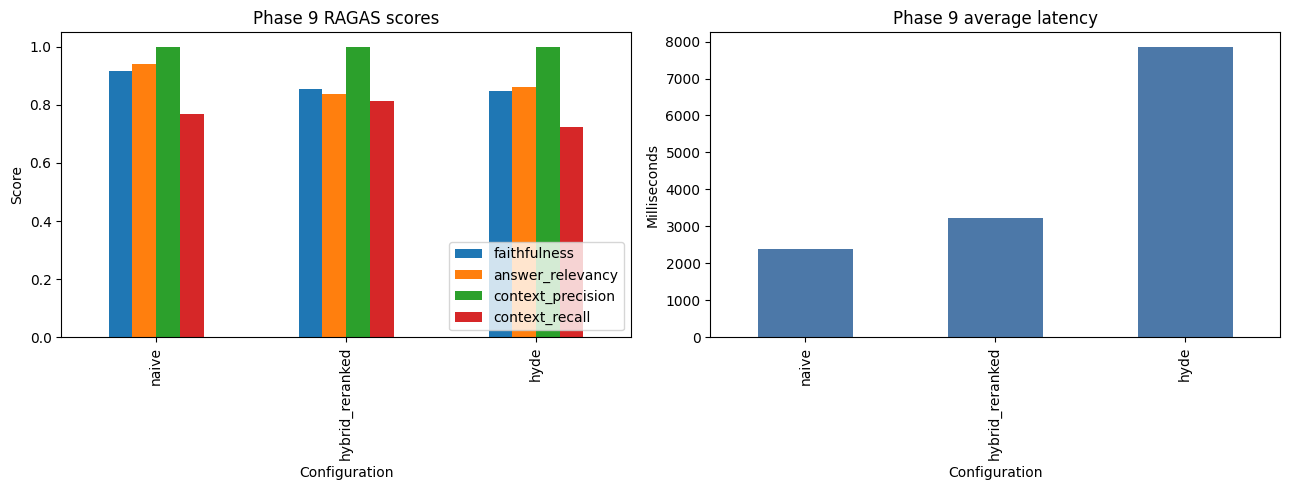

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metric_cols = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]
ragas_df[metric_cols].plot(kind="bar", ax=axes[0])
axes[0].set_title("Phase 9 RAGAS scores")
axes[0].set_ylim(0, 1.05)
axes[0].set_xlabel("Configuration")
axes[0].set_ylabel("Score")
axes[0].legend(loc="lower right")

ragas_df["avg_latency_ms"].plot(kind="bar", ax=axes[1], color="#4c78a8")
axes[1].set_title("Phase 9 average latency")
axes[1].set_xlabel("Configuration")
axes[1].set_ylabel("Milliseconds")

plt.tight_layout()
plt.show()

## 9. Save the Assembled Pipeline Report

In [16]:
RESULTS_DIR.mkdir(exist_ok=True)

report = {
    "experiment": "phase10_full_pipeline",
    "decision": final_decision,
    "component_summary": component_summary,
    "collection_name": COLLECTION_NAME,
    "index_time_s": index_time_s,
    "current_run": {
        "generation_benchmark_ran": RUN_GENERATION_BENCHMARK,
        "ragas_ran": RUN_RAGAS,
        "num_questions": len(ground_truths),
        "latency_summary": latency_summary,
        "ragas_scores": ragas_scores,
    },
    "phase9_reference": ragas_result,
}

if benchmark_samples:
    report["current_run"]["samples"] = [
        {
            "id": sample.question_id,
            "category": sample.category,
            "question": sample.question,
            "answer": sample.answer,
            "latency_ms": sample.latency_ms,
            "num_contexts": len(sample.contexts),
        }
        for sample in benchmark_samples
    ]

output_path = RESULTS_DIR / "full_pipeline.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print(f"Saved full pipeline report -> {output_path}")

Saved full pipeline report -> /home/hunganh/Code/Python/course_qa_assist/results/full_pipeline.json


## 10. Conclusion

### Final pipeline

| Component | Choice | Evidence |
|---|---|---|
| Corpus | `data/lectures` PDFs | Phase 1 loaded 2,703 pages and retained 2,666 cleaned pages |
| Chunking | Recursive, 1000 chars, 200 overlap | Phase 2 had the best balance of score, speed, and simple reproducibility |
| Embeddings | `mxbai_large` | Phase 3 selected the strongest local embedding option for this corpus |
| Retrieval | Similarity top-5 | Phase 9 `naive` won end-to-end RAGAS |
| Reranking | Disabled by default | Phase 7 cross-encoder improved retrieval-only scores, but Phase 9 `hybrid_reranked` lost end-to-end |
| LLM | `mistral:7b`, temperature 0.0 | Used consistently in Phases 8-9 |

### Reference Phase 9 scores

| Config | Faithfulness | Answer Relevancy | Context Precision | Context Recall | Avg Score | Avg Latency |
|---|---:|---:|---:|---:|---:|---:|
| naive | 0.9181 | 0.9402 | 1.0000 | 0.7679 | 0.9065 | 2384.6 ms |
| hybrid_reranked | 0.8542 | 0.8375 | 1.0000 | 0.8139 | 0.8764 | 3235.0 ms |
| hyde | 0.8491 | 0.8633 | 1.0000 | 0.7253 | 0.8594 | 7857.3 ms |

### Operational note

Use `hybrid_reranked` only as a recall-focused mode when missing context is more costly than extra latency and slightly lower answer quality. Keep the default pipeline as `naive` until a larger ground truth set changes the end-to-end result.